In [31]:
# ============================================================================
# CELLULE 1 - Installation et imports
# ============================================================================

!pip install kaggle plotly optuna lightgbm xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

print(f"✅ Pandas  : {pd.__version__}")
print(f"✅ NumPy   : {np.__version__}")
print(f"✅ Plotly  : {plotly.__version__}")

# Optuna et modèles
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit

print(f"✅ Optuna   : {optuna.__version__}")
print(f"✅ LightGBM : {lgb.__version__}")
print(f"✅ XGBoost  : {xgb.__version__}")

✅ Pandas  : 2.2.2
✅ NumPy   : 2.0.2
✅ Plotly  : 5.24.1
✅ Optuna   : 4.9.0
✅ LightGBM : 4.6.0
✅ XGBoost  : 3.2.0


In [ ]:
# ============================================================================
# CELLULE 2 - Upload de la clé Kaggle
# ============================================================================

from google.colab import files

print("→ Sélectionne ton fichier kaggle.json")
uploaded = files.upload()

import os, shutil
os.makedirs("/root/.config/kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

print("✅ Clé Kaggle configurée")

In [33]:
# ============================================================================
# CELLULE 3 - Téléchargement du dataset
# ============================================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
DEST = "/content/drive/MyDrive/datasets/f1_ergast2"
os.makedirs(DEST, exist_ok=True)

!kaggle datasets download -d rohanrao/formula-1-world-championship-1950-2020 \
    --path "{DEST}" \
    --unzip

print(f"\n✅ Fichiers disponibles dans {DEST} :")
for f in sorted(os.listdir(DEST)):
    size_kb = os.path.getsize(f"{DEST}/{f}") / 1024
    print(f"  {f:30s} {size_kb:>8.0f} Ko")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset URL: https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020
License(s): CC0-1.0
100% 6.28M/6.28M [00:00<00:00, 65.0MB/s]


✅ Fichiers disponibles dans /content/drive/MyDrive/datasets/f1_ergast2 :
  circuits.csv                         10 Ko
  constructor_results.csv             214 Ko
  constructor_standings.csv           310 Ko
  constructors.csv                     17 Ko
  driver_standings.csv                863 Ko
  drivers.csv                          92 Ko
  lap_times.csv                     17209 Ko
  pit_stops.csv                       433 Ko
  pitstops_clean.csv                 3646 Ko
  qualifying.csv                      454 Ko
  races.csv                           160 Ko
  results.csv                        1682 Ko
  seasons.csv                           4 Ko
  sprint_results.csv                   24 Ko
  status.csv

In [34]:
# ============================================================================
# CELLULE 4 - Chargement des données
# ============================================================================

DATA_ROOT = "/content/drive/MyDrive/datasets/f1_ergast2"

# 1. Pit stops
pit_stops = pd.read_csv(
    f"{DATA_ROOT}/pit_stops.csv",
    usecols=["raceId", "driverId", "stop", "lap", "duration", "milliseconds"],
    dtype={"raceId": "int32", "driverId": "int32", "stop": "int8",
           "lap": "int16", "duration": "object", "milliseconds": "float32"},
    na_values=["\\N", ""],
)
print(f"Pit stops shape : {pit_stops.shape}")

# 2. Races
races = pd.read_csv(
    f"{DATA_ROOT}/races.csv",
    usecols=["raceId", "year", "round", "circuitId", "name", "date"],
    dtype={"raceId": "int32", "year": "int16", "round": "int8",
           "circuitId": "int16", "name": "category"},
    na_values=["\\N", ""],
)

# 3. Circuits
circuits = pd.read_csv(
    f"{DATA_ROOT}/circuits.csv",
    usecols=["circuitId", "name", "location", "country", "lat", "lng", "alt"],
    dtype={"circuitId": "int16", "name": "category", "location": "category",
           "country": "category", "lat": "float32", "lng": "float32", "alt": "float32"},
    na_values=["\\N", ""],
)

# 4. Drivers
drivers = pd.read_csv(
    f"{DATA_ROOT}/drivers.csv",
    usecols=["driverId", "driverRef", "nationality", "dob"],
    dtype={"driverId": "int32", "driverRef": "category", "nationality": "category"},
    na_values=["\\N", ""],
)

# 5. Results
results = pd.read_csv(
    f"{DATA_ROOT}/results.csv",
    usecols=["raceId", "driverId", "constructorId", "grid",
             "positionOrder", "points", "laps", "statusId"],
    dtype={"raceId": "int32", "driverId": "int32", "constructorId": "int16",
           "grid": "int8", "positionOrder": "int8", "points": "float32",
           "laps": "int16", "statusId": "int16"},
    na_values=["\\N", ""],
)

# 6. Constructors
constructors = pd.read_csv(
    f"{DATA_ROOT}/constructors.csv",
    usecols=["constructorId", "constructorRef", "name", "nationality"],
    dtype={"constructorId": "int16", "constructorRef": "category",
           "name": "category", "nationality": "category"},
    na_values=["\\N", ""],
)

# 7. Status
status = pd.read_csv(
    f"{DATA_ROOT}/status.csv",
    usecols=["statusId", "status"],
    dtype={"statusId": "int16", "status": "category"},
    na_values=["\\N", ""],
)

# 8. Lap times
lap_times = pd.read_csv(
    f"{DATA_ROOT}/lap_times.csv",
    usecols=["raceId", "driverId", "lap", "position", "milliseconds"],
    dtype={"raceId": "int32", "driverId": "int32", "lap": "int16",
           "position": "int8", "milliseconds": "int32"},
    na_values=["\\N", ""],
)

print(f"Lap times shape : {lap_times.shape}")

# Agrégation lap_times
lap_agg = (
    lap_times
    .rename(columns={"milliseconds": "lap_time_ms", "position": "lap_position"})
    .groupby(["raceId", "driverId", "lap"], as_index=False)
    .first()
)
del lap_times
print(f"Lap_agg shape : {lap_agg.shape}")

Pit stops shape : (11371, 6)
Lap times shape : (589081, 5)
Lap_agg shape : (589081, 5)


In [35]:
# ============================================================================
# CELLULE 5 - Nettoyage de la variable cible
# ============================================================================

print(f"Lignes initiales : {len(pit_stops):,}")

# Filtre sur milliseconds
mask = pit_stops["milliseconds"].between(1_000, 120_000)
pit_stops = pit_stops[mask].copy()
print(f"Après filtre [1s–120s] : {len(pit_stops):,} ({mask.sum()/mask.count():.1%} conservées)")

# Parse duration
def parse_duration(x):
    try:
        if isinstance(x, str) and ":" in x:
            m, s = x.split(":")
            return float(m) * 60 + float(s)
        return float(x)
    except (ValueError, TypeError):
        return np.nan

pit_stops["duration_sec"] = pit_stops["duration"].apply(parse_duration)
pit_stops.drop(columns=["duration"], inplace=True)

print(f"\nDistribution milliseconds :")
print(pit_stops["milliseconds"].describe())

Lignes initiales : 11,371
Après filtre [1s–120s] : 10,890 (95.8% conservées)

Distribution milliseconds :
count     10890.000000
mean      24626.958984
std        5612.632812
min       12897.000000
25%       21869.000000
50%       23445.000000
75%       25676.000000
max      109329.000000
Name: milliseconds, dtype: float64


In [36]:
# ============================================================================
# CELLULE 6 - Jointures
# ============================================================================

# Conversions
races["date"] = pd.to_datetime(races["date"], errors="coerce")
drivers["dob"] = pd.to_datetime(drivers["dob"], errors="coerce")
circuits["alt"] = circuits["alt"].fillna(circuits["alt"].median())

# 1. pit_stops × races
df = pit_stops.merge(races.rename(columns={"name": "race_name"}), on="raceId", how="left")
print(f"× races        → {df.shape}")

# 2. × circuits
df = df.merge(circuits.rename(columns={"name": "circuit_name"}), on="circuitId", how="left")
print(f"× circuits     → {df.shape}")

# 3. × drivers
df = df.merge(drivers, on="driverId", how="left")
df["driver_age"] = ((df["date"] - df["dob"]).dt.days / 365.25).astype("float32")
df.drop(columns=["dob"], inplace=True)
print(f"× drivers      → {df.shape}")

# 4. × results
df = df.merge(results, on=["raceId", "driverId"], how="left")
print(f"× results      → {df.shape}")

# 5. × constructors
df = df.merge(
    constructors.rename(columns={"name": "constructor_name", "nationality": "constructor_nat"}),
    on="constructorId", how="left"
)
print(f"× constructors → {df.shape}")

# 6. × status
df = df.merge(status, on="statusId", how="left")
print(f"× status       → {df.shape}")

# 7. × lap_times
df = df.merge(lap_agg, on=["raceId", "driverId", "lap"], how="left")
print(f"× lap_times    → {df.shape}")

× races        → (10890, 11)
× circuits     → (10890, 17)
× drivers      → (10890, 20)
× results      → (10890, 26)
× constructors → (10890, 29)
× status       → (10890, 30)
× lap_times    → (10890, 32)


In [78]:
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import numpy as np
import pandas as pd
import plotly.io as pio

print("="*60)
print("📊 ANALYSE EXPLORATOIRE - Génération de tous les graphiques")
print("="*60)

# Forcer l'affichage Plotly dans Colab
pio.renderers.default = 'colab'

# Préparation des données
df_clean = df.copy()

# ============================================================================
# CRÉATION DES 13 GRAPHIQUES
# ============================================================================

# Graphique 1: Distribution
fig1 = px.histogram(df_clean, x="milliseconds", nbins=50,
                    title="📊 Distribution des durées d'arrêt au stand",
                    labels={"milliseconds": "Durée (millisecondes)", "count": "Nombre d'arrêts"})
median_val = df_clean["milliseconds"].median()
fig1.add_vline(x=median_val, line_dash="dash", line_color="red",
               annotation_text=f"Médiane: {median_val:.0f} ms")
fig1.update_layout(height=500, width=900)

# Graphique 2: Évolution par année
yearly_avg = df_clean.groupby("year")["milliseconds"].mean().reset_index()
fig2 = px.line(yearly_avg, x="year", y="milliseconds",
               title="📈 Évolution de la durée moyenne des arrêts",
               labels={"year": "Année", "milliseconds": "Durée moyenne (ms)"},
               markers=True)
fig2.update_layout(height=500, width=900)

# Graphique 3: Top 10 circuits RAPIDES
circuit_stats = df_clean.groupby("circuit_name")["milliseconds"].mean().sort_values().reset_index()
fig3 = px.bar(circuit_stats.head(10), x="milliseconds", y="circuit_name",
              title="🏁 Top 10 circuits - Arrêts les PLUS RAPIDES",
              labels={"milliseconds": "Durée moyenne (ms)", "circuit_name": "Circuit"},
              orientation="h", color="milliseconds", color_continuous_scale="Viridis_r")
fig3.update_layout(height=500, width=900)

# Graphique 4: Top 10 circuits LENTS
fig4 = px.bar(circuit_stats.tail(10), x="milliseconds", y="circuit_name",
              title="🐢 Top 10 circuits - Arrêts les PLUS LENTS",
              labels={"milliseconds": "Durée moyenne (ms)", "circuit_name": "Circuit"},
              orientation="h", color="milliseconds", color_continuous_scale="Reds")
fig4.update_layout(height=500, width=900)

# Graphique 5: Top 10 écuries RAPIDES
constructor_stats = df_clean.groupby("constructor_name")["milliseconds"].mean().sort_values().reset_index()
fig5 = px.bar(constructor_stats.head(10), x="milliseconds", y="constructor_name",
              title="🏎️ Top 10 écuries - Arrêts les PLUS RAPIDES",
              labels={"milliseconds": "Durée moyenne (ms)", "constructor_name": "Écurie"},
              orientation="h", color="milliseconds", color_continuous_scale="Viridis_r")
fig5.update_layout(height=500, width=900)

# Graphique 6: Top 10 écuries LENTES
fig6 = px.bar(constructor_stats.tail(10), x="milliseconds", y="constructor_name",
              title="🐌 Top 10 écuries - Arrêts les PLUS LENTS",
              labels={"milliseconds": "Durée moyenne (ms)", "constructor_name": "Écurie"},
              orientation="h", color="milliseconds", color_continuous_scale="Reds")
fig6.update_layout(height=500, width=900)

# Graphique 7: Position de départ
df_clean["grid_group"] = pd.cut(df_clean["grid"], bins=[0, 3, 6, 10, 20, 100],
                                 labels=["Top 3", "4-6", "7-10", "11-20", "20+"])
fig7 = px.box(df_clean, x="grid_group", y="milliseconds",
              title="🏁 Position de départ vs Durée d'arrêt",
              labels={"grid_group": "Position sur grille", "milliseconds": "Durée (ms)"},
              color="grid_group")
fig7.update_layout(height=500, width=900)

# Graphique 8: Top 10 pays RAPIDES
country_stats = df_clean.groupby("country")["milliseconds"].mean().sort_values().reset_index()
fig8 = px.bar(country_stats.head(10), x="milliseconds", y="country",
              title="🌍 Top 10 pays - Arrêts les plus rapides",
              labels={"milliseconds": "Durée moyenne (ms)", "country": "Pays"},
              orientation="h", color="milliseconds", color_continuous_scale="Blues_r")
fig8.update_layout(height=500, width=900)

# Graphique 9: Matrice de corrélation
numeric_cols = ["milliseconds", "driver_age", "grid", "positionOrder", "points", "lap", "stop"]
corr_matrix = df_clean[numeric_cols].corr()
fig9 = px.imshow(corr_matrix, text_auto=True, aspect="auto",
                 title="🔗 Matrice de corrélation",
                 labels={"color": "Corrélation", "x": "Variable", "y": "Variable"},
                 color_continuous_scale="RdBu_r", zmin=-1, zmax=1)
fig9.update_layout(height=600, width=800)

# Graphique 10: Carte mondiale
world_avg = df_clean.groupby(["country", "lat", "lng"])["milliseconds"].mean().reset_index()
world_avg = world_avg.dropna(subset=['milliseconds'])
fig10 = px.scatter_geo(world_avg, lat="lat", lon="lng",
                       size="milliseconds", color="milliseconds",
                       hover_name="country",
                       title="🗺️ Carte mondiale - Durée moyenne des arrêts",
                       labels={"milliseconds": "Durée moyenne (ms)"},
                       color_continuous_scale="Viridis_r",
                       size_max=40)
fig10.update_layout(height=600, width=1000)

# Graphique 11: Évolution par décennie
df_clean["decade"] = (df_clean["year"] // 10) * 10
decade_stats = df_clean.groupby("decade")["milliseconds"].mean().reset_index()
fig11 = px.bar(decade_stats, x="decade", y="milliseconds",
               title="📅 Évolution par décennie",
               labels={"decade": "Décennie", "milliseconds": "Durée moyenne (ms)"},
               color="milliseconds", color_continuous_scale="Viridis")
fig11.update_layout(height=500, width=900)

# Graphique 12: Violin plot
top_circuits = df_clean["circuit_name"].value_counts().head(10).index
df_top_circuits = df_clean[df_clean["circuit_name"].isin(top_circuits)]
fig12 = px.violin(df_top_circuits, x="circuit_name", y="milliseconds",
                  title="🎻 Distribution des arrêts - Top 10 circuits",
                  labels={"circuit_name": "Circuit", "milliseconds": "Durée (ms)"},
                  box=True, points="all")
fig12.update_layout(height=600, width=1100, xaxis_tickangle=45)

# Graphique 13: Âge du pilote
df_clean["age_group"] = pd.cut(df_clean["driver_age"], bins=[0, 25, 30, 35, 40, 100],
                                labels=["<25 ans", "25-30 ans", "30-35 ans", "35-40 ans", "40+ ans"])
fig13 = px.box(df_clean, x="age_group", y="milliseconds",
               title="👤 Âge du pilote vs Durée d'arrêt",
               labels={"age_group": "Tranche d'âge", "milliseconds": "Durée (ms)"},
               color="age_group")
fig13.update_layout(height=500, width=900)

# Afficher dans Colab
print("📊 Affichage dans Colab...")
for fig in [fig1, fig2, fig3, fig4, fig5, fig6, fig7, fig8, fig9, fig10, fig11, fig12, fig13]:
    fig.show()

# ============================================================================
# GÉNÉRATION DU HTML (UNE SEULE FOIS)
# ============================================================================

print("\n📄 Génération du rapport HTML...")

# Créer un dictionnaire pour stocker les JSON
graphs_json = {}
for i, fig in enumerate([fig1, fig2, fig3, fig4, fig5, fig6, fig7, fig8, fig9, fig10, fig11, fig12, fig13], 1):
    graphs_json[f'graph{i}'] = pio.to_json(fig)

html_content = f'''<!DOCTYPE html>
<html lang="fr">
<head>
    <meta charset="UTF-8">
    <title>Analyse F1 - Arrêts aux stands</title>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 0; padding: 20px; background: #f0f2f5; }}
        .container {{ max-width: 1200px; margin: 0 auto; }}
        .header {{ background: linear-gradient(135deg, #1a1a2e, #16213e); color: white; padding: 30px; border-radius: 10px; margin-bottom: 20px; text-align: center; }}
        .stats-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(180px, 1fr)); gap: 15px; margin-bottom: 30px; }}
        .stat-card {{ background: white; padding: 20px; border-radius: 10px; text-align: center; box-shadow: 0 2px 5px rgba(0,0,0,0.1); }}
        .stat-card .value {{ font-size: 1.8em; font-weight: bold; color: #e10600; }}
        .graph-container {{ background: white; border-radius: 10px; padding: 20px; margin-bottom: 25px; box-shadow: 0 2px 5px rgba(0,0,0,0.1); }}
        .graph-title {{ font-size: 1.2em; font-weight: bold; margin-bottom: 15px; color: #333; border-left: 4px solid #e10600; padding-left: 12px; }}
        .two-columns {{ display: grid; grid-template-columns: 1fr 1fr; gap: 20px; }}
        .btn-download {{ background: #e10600; color: white; padding: 12px 30px; font-size: 16px; border: none; border-radius: 25px; cursor: pointer; margin: 20px auto; display: block; }}
        .btn-download:hover {{ background: #c00500; }}
        .footer {{ text-align: center; padding: 20px; color: #666; }}
        @media (max-width: 768px) {{ .two-columns {{ grid-template-columns: 1fr; }} }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>🏎️ FORMULA 1 - ANALYSE DES ARRÊTS AUX STANDS</h1>
            <p>Rapport généré le {datetime.now().strftime("%d/%m/%Y à %H:%M:%S")}</p>
            <p>📊 {len(df_clean):,} arrêts analysés | 📅 Période {df_clean['year'].min()} - {df_clean['year'].max()}</p>
        </div>

        <div class="stats-grid">
            <div class="stat-card"><div class="value">{df_clean['milliseconds'].mean()/1000:.2f} sec</div><div>Durée moyenne</div></div>
            <div class="stat-card"><div class="value">{df_clean['milliseconds'].median()/1000:.2f} sec</div><div>Durée médiane</div></div>
            <div class="stat-card"><div class="value">{df_clean['milliseconds'].min()/1000:.2f} sec</div><div>Arrêt le plus rapide</div></div>
            <div class="stat-card"><div class="value">{df_clean['milliseconds'].max()/1000:.2f} sec</div><div>Arrêt le plus long</div></div>
        </div>

        <div class="graph-container"><div class="graph-title">📊 Distribution des durées d'arrêt</div><div id="graph1"></div></div>
        <div class="graph-container"><div class="graph-title">📈 Évolution temporelle (2011-2024)</div><div id="graph2"></div></div>

        <div class="two-columns">
            <div class="graph-container"><div class="graph-title">🏁 Top 10 circuits RAPIDES</div><div id="graph3"></div></div>
            <div class="graph-container"><div class="graph-title">🐢 Top 10 circuits LENTS</div><div id="graph4"></div></div>
        </div>

        <div class="two-columns">
            <div class="graph-container"><div class="graph-title">🏎️ Top 10 écuries RAPIDES</div><div id="graph5"></div></div>
            <div class="graph-container"><div class="graph-title">🐌 Top 10 écuries LENTES</div><div id="graph6"></div></div>
        </div>

        <div class="graph-container"><div class="graph-title">🏁 Position de départ vs Durée d'arrêt</div><div id="graph7"></div></div>
        <div class="graph-container"><div class="graph-title">🌍 Top 10 pays RAPIDES</div><div id="graph8"></div></div>
        <div class="graph-container"><div class="graph-title">🔗 Matrice de corrélation</div><div id="graph9"></div></div>
        <div class="graph-container"><div class="graph-title">🗺️ Carte mondiale</div><div id="graph10"></div></div>
        <div class="graph-container"><div class="graph-title">📅 Évolution par décennie</div><div id="graph11"></div></div>
        <div class="graph-container"><div class="graph-title">🎻 Distribution - Top 10 circuits</div><div id="graph12"></div></div>
        <div class="graph-container"><div class="graph-title">👤 Âge du pilote vs Durée</div><div id="graph13"></div></div>

        <button class="btn-download" onclick="window.print()">📥 TÉLÉCHARGER LE RAPPORT (PDF)</button>
        <div class="footer">Analyse réalisée avec Plotly | Données Ergast F1 (2011-2024)</div>
    </div>

    <script>
        var graph1 = {graphs_json['graph1']};
        Plotly.newPlot('graph1', graph1.data, graph1.layout, {{responsive: true}});

        var graph2 = {graphs_json['graph2']};
        Plotly.newPlot('graph2', graph2.data, graph2.layout, {{responsive: true}});

        var graph3 = {graphs_json['graph3']};
        Plotly.newPlot('graph3', graph3.data, graph3.layout, {{responsive: true}});

        var graph4 = {graphs_json['graph4']};
        Plotly.newPlot('graph4', graph4.data, graph4.layout, {{responsive: true}});

        var graph5 = {graphs_json['graph5']};
        Plotly.newPlot('graph5', graph5.data, graph5.layout, {{responsive: true}});

        var graph6 = {graphs_json['graph6']};
        Plotly.newPlot('graph6', graph6.data, graph6.layout, {{responsive: true}});

        var graph7 = {graphs_json['graph7']};
        Plotly.newPlot('graph7', graph7.data, graph7.layout, {{responsive: true}});

        var graph8 = {graphs_json['graph8']};
        Plotly.newPlot('graph8', graph8.data, graph8.layout, {{responsive: true}});

        var graph9 = {graphs_json['graph9']};
        Plotly.newPlot('graph9', graph9.data, graph9.layout, {{responsive: true}});

        var graph10 = {graphs_json['graph10']};
        Plotly.newPlot('graph10', graph10.data, graph10.layout, {{responsive: true}});

        var graph11 = {graphs_json['graph11']};
        Plotly.newPlot('graph11', graph11.data, graph11.layout, {{responsive: true}});

        var graph12 = {graphs_json['graph12']};
        Plotly.newPlot('graph12', graph12.data, graph12.layout, {{responsive: true}});

        var graph13 = {graphs_json['graph13']};
        Plotly.newPlot('graph13', graph13.data, graph13.layout, {{responsive: true}});
    </script>
</body>
</html>'''

# Sauvegarder et télécharger
with open("/content/rapport_f1_pitstops.html", "w", encoding="utf-8") as f:
    f.write(html_content)

from google.colab import files
files.download("/content/rapport_f1_pitstops.html")

print("\n" + "="*60)
print("✅ RAPPORT GÉNÉRÉ AVEC 13 GRAPHIQUES")
print("📁 Fichier : rapport_f1_pitstops.html")
print("="*60)

📊 ANALYSE EXPLORATOIRE - Génération de tous les graphiques
📊 Affichage dans Colab...



📄 Génération du rapport HTML...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ RAPPORT GÉNÉRÉ AVEC 13 GRAPHIQUES
📁 Fichier : rapport_f1_pitstops.html


In [38]:
# - Nettoyage outliers & doublons

print("="*60)
print("📊 NETTOYAGE DES DONNÉES")
print("="*60)

print(f"Avant nettoyage : {len(df):,} lignes")

# Supprimer doublons stricts
df = df.drop_duplicates(subset=["raceId", "driverId", "stop"])

# IQR sur la variable cible pour éliminer outliers extrêmes
Q1 = df["milliseconds"].quantile(0.01)
Q3 = df["milliseconds"].quantile(0.99)
df = df[df["milliseconds"].between(Q1, Q3)].copy()

print(f"Après nettoyage  : {len(df):,} lignes")
print(f"Plage cible conservée : [{Q1:.0f} ms, {Q3:.0f} ms]")

📊 NETTOYAGE DES DONNÉES
Avant nettoyage : 10,890 lignes
Après nettoyage  : 10,672 lignes
Plage cible conservée : [16473 ms, 43920 ms]


In [39]:
# ============================================================================
# CELLULE 8 - Feature Engineering 1 : Historique de l'arrêt (SANS FUITE)
# ============================================================================

print("="*60)
print("📊 FEATURE 1 - Historique des arrêts")
print("="*60)

df = df.sort_values(["raceId", "driverId", "stop"]).reset_index(drop=True)

df["stop_number"] = df["stop"].astype("int8")
df["stops_so_far"] = (df["stop_number"] - 1).astype("int8")

total_stops = df.groupby(["raceId", "driverId"])["stop"].transform("max").astype("int8")
df["total_stops_race"] = total_stops
df["is_last_stop"] = (df["stop_number"] == df["total_stops_race"]).astype("int8")

print("✅ Features historiques créées")
print(df[["raceId", "driverId", "stop_number", "stops_so_far", "total_stops_race", "is_last_stop"]].head(8))

📊 FEATURE 1 - Historique des arrêts
✅ Features historiques créées
   raceId  driverId  stop_number  stops_so_far  total_stops_race  is_last_stop
0     841         1            1             0                 2             0
1     841         1            2             1                 2             1
2     841         2            1             0                 2             0
3     841         2            2             1                 2             1
4     841         3            1             0                 1             1
5     841         4            1             0                 3             0
6     841         4            2             1                 3             0
7     841         4            3             2                 3             1


In [40]:
# ============================================================================
# CELLULE 9 - Feature Engineering 2 : Progression de course (CORRIGÉ)
# ============================================================================

print("="*60)
print("📊 FEATURE 2 - Progression de course (sans fuite)")
print("="*60)

if 'total_laps' not in df.columns:
    total_laps_per_race = df.groupby('raceId')['lap'].max().reset_index()
    total_laps_per_race.columns = ['raceId', 'total_laps']
    df = df.merge(total_laps_per_race, on='raceId', how='left')

df["race_progress"] = (df["lap"] / df["total_laps"]).astype("float32")
df["race_phase"] = pd.cut(df["race_progress"], bins=[0, 0.33, 0.66, 1.01],
                          labels=["early", "mid", "late"]).astype("category")
print("✅ race_progress et race_phase créés")

df["position_at_stop"] = df["lap_position"].astype("float32")
print("✅ position_at_stop créé")

df = df.sort_values(["raceId", "driverId", "stop"])
prev_lap = df.groupby(["raceId", "driverId"])["lap"].shift(1).fillna(0)
df["laps_since_last_stop"] = (df["lap"] - prev_lap).astype("float32")
print("✅ laps_since_last_stop créé")

# 🔥 CORRECTION : lap_time_delta basé sur les tours passés
def compute_lap_time_performance(group):
    results = []
    for i in range(len(group)):
        if i == 0:
            results.append(0.0)
        else:
            avg_previous = group.iloc[:i].mean()
            current = group.iloc[i]
            if avg_previous > 0:
                results.append((current - avg_previous) / avg_previous)
            else:
                results.append(0.0)
    return results

df['lap_time_delta'] = df.groupby(['raceId', 'driverId'])['lap_time_ms'].transform(
    lambda x: compute_lap_time_performance(x)
).astype('float32')

print("✅ lap_time_delta CORRIGÉ - n'utilise que les tours passés")

📊 FEATURE 2 - Progression de course (sans fuite)
✅ race_progress et race_phase créés
✅ position_at_stop créé
✅ laps_since_last_stop créé
✅ lap_time_delta CORRIGÉ - n'utilise que les tours passés


In [41]:
# ============================================================================
# CELLULE 10 - Feature Engineering 3 : Moyennes glissantes (CORRIGÉ)
# ============================================================================

print("="*60)
print("📊 FEATURE 3 - Moyennes glissantes (sans fuite)")
print("="*60)

def safe_rolling_mean(group, window):
    values = group['milliseconds'].values
    results = []
    for i in range(len(values)):
        if i == 0:
            results.append(np.nan)
        else:
            start = max(0, i - window)
            results.append(np.mean(values[start:i]))
    return results

df = df.sort_values(['year', 'round', 'raceId', 'driverId', 'stop']).reset_index(drop=True)

print("\n📊 Rolling averages par pilote :")
for window in [3, 5]:
    col_name = f'driver_avg_last_{window}'
    df[col_name] = df.groupby('driverId', group_keys=False).apply(
        lambda g: pd.Series(safe_rolling_mean(g, window), index=g.index)
    ).astype('float32')
    print(f"   {col_name} créé (NaN: {df[col_name].isna().sum()})")

print("\n📊 Rolling averages par constructeur :")
for window in [3, 5]:
    col_name = f'constructor_avg_last_{window}'
    df[col_name] = df.groupby('constructorId', group_keys=False).apply(
        lambda g: pd.Series(safe_rolling_mean(g, window), index=g.index)
    ).astype('float32')
    print(f"   {col_name} créé (NaN: {df[col_name].isna().sum()})")

print("\n📊 Rolling averages par circuit :")
df['circuit_avg_last_5'] = df.groupby('circuitId', group_keys=False).apply(
    lambda g: pd.Series(safe_rolling_mean(g, 5), index=g.index)
).astype('float32')
print(f"   circuit_avg_last_5 créé (NaN: {df['circuit_avg_last_5'].isna().sum()})")

print("\n✅ Toutes les rolling averages sont maintenant SANS FUITE de données !")

📊 FEATURE 3 - Moyennes glissantes (sans fuite)

📊 Rolling averages par pilote :
   driver_avg_last_3 créé (NaN: 76)
   driver_avg_last_5 créé (NaN: 76)

📊 Rolling averages par constructeur :
   constructor_avg_last_3 créé (NaN: 23)
   constructor_avg_last_5 créé (NaN: 23)

📊 Rolling averages par circuit :
   circuit_avg_last_5 créé (NaN: 35)

✅ Toutes les rolling averages sont maintenant SANS FUITE de données !


In [42]:
# ============================================================================
# CELLULE 11 - Feature Engineering 4 : Encodage catégoriel (CORRIGÉ)
# ============================================================================

print("="*60)
print("📊 FEATURE 4 - Encodage des variables catégorielles")
print("="*60)

def safe_target_encode(df, col, target_col, train_mask, alpha=10):
    train_data = df[train_mask]
    global_mean = train_data[target_col].mean()
    stats = train_data.groupby(col)[target_col].agg(['mean', 'count'])
    smoothed = (stats['count'] * stats['mean'] + alpha * global_mean) / (stats['count'] + alpha)
    return df[col].map(smoothed).fillna(global_mean).astype('float32')

categorical_cols = ['circuit_name', 'constructor_name', 'driverRef', 'nationality']
print(f"Colonnes à encoder : {categorical_cols}")

train_mask = df['year'] <= 2021
print(f"Masque d'entraînement : années ≤ 2021 ({train_mask.sum():,} lignes)")

for col in categorical_cols:
    if col in df.columns:
        encoded_name = f'{col}_te'
        df[encoded_name] = safe_target_encode(df, col, 'milliseconds', train_mask)
        print(f"✅ {col:20} → {encoded_name}")

print("\n✅ Target encoding terminé SANS fuite de données !")

📊 FEATURE 4 - Encodage des variables catégorielles
Colonnes à encoder : ['circuit_name', 'constructor_name', 'driverRef', 'nationality']
Masque d'entraînement : années ≤ 2021 (8,382 lignes)
✅ circuit_name         → circuit_name_te
✅ constructor_name     → constructor_name_te
✅ driverRef            → driverRef_te
✅ nationality          → nationality_te

✅ Target encoding terminé SANS fuite de données !


In [47]:
# ============================================================================
# CELLULE 12 - Préparation des données pour la modélisation
# ============================================================================

print("="*60)
print("📊 PRÉPARATION DES DONNÉES POUR LA MODÉLISATION")
print("="*60)

# Supprimer duration_sec (corrélation parfaite avec milliseconds)
if 'duration_sec' in df.columns:
    df = df.drop(columns=['duration_sec'])
    print("✅ duration_sec supprimé")

# Colonnes à exclure
DROP_COLS = ['raceId', 'driverId', 'constructorId', 'circuitId', 'statusId',
             'date', 'race_name', 'circuit_name', 'lap_time_ms', 'stop',
             'location', 'country', 'f1_era', 'race_phase',
             'driverRef', 'nationality', 'constructor_name', 'status']

drop_existing = [c for c in DROP_COLS if c in df.columns]
df_model = df.drop(columns=drop_existing)

print(f"Shape après nettoyage : {df_model.shape}")

# Séparation X / y
X = df_model.drop(columns=['milliseconds'])
y = df_model['milliseconds']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

📊 PRÉPARATION DES DONNÉES POUR LA MODÉLISATION
Shape après nettoyage : (10672, 33)
X shape : (10672, 32)
y shape : (10672,)


In [44]:
# ============================================================================
# CELLULE 13 - Split temporel (TimeSeriesSplit - SANS FUITE)
# ============================================================================

print("="*60)
print("📊 SPLIT TEMPOREL (TimeSeriesSplit)")
print("="*60)

CUTOFF_YEAR = 2021

train_mask = df_model['year'] <= CUTOFF_YEAR
test_mask = df_model['year'] > CUTOFF_YEAR

X_train = X[train_mask].drop(columns=['year'], errors='ignore')
X_test = X[test_mask].drop(columns=['year'], errors='ignore')
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Train : {X_train.shape}  → années {df_model.loc[train_mask,'year'].min()}–{df_model.loc[train_mask,'year'].max()}")
print(f"Test  : {X_test.shape}  → années {df_model.loc[test_mask,'year'].min()}–{df_model.loc[test_mask,'year'].max()}")
print(f"Répartition : {len(X_train)/(len(X_train)+len(X_test)):.0%} train / {len(X_test)/(len(X_train)+len(X_test)):.0%} test")

# TimeSeriesSplit pour la cross-validation
tscv = TimeSeriesSplit(n_splits=4, gap=0)

# Trier chronologiquement pour la CV
year_train = df_model.loc[train_mask, 'year'].values
sorted_idx = np.argsort(year_train)
X_train_sorted = X_train.iloc[sorted_idx].reset_index(drop=True)
y_train_sorted = y_train.iloc[sorted_idx].reset_index(drop=True)

print("\n✅ Configuration TimeSeriesSplit :")
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_sorted), 1):
    yr_tr = year_train[sorted_idx][tr_idx]
    yr_val = year_train[sorted_idx][val_idx]
    print(f"  Fold {fold} → train {yr_tr.min()}–{yr_tr.max()} ({len(tr_idx):,} lignes) | val {yr_val.min()}–{yr_val.max()} ({len(val_idx):,} lignes)")

📊 SPLIT TEMPOREL (TimeSeriesSplit)
Train : (8382, 38)  → années 2011–2021
Test  : (2290, 38)  → années 2022–2024
Répartition : 79% train / 21% test

✅ Configuration TimeSeriesSplit :
  Fold 1 → train 2011–2012 (1,678 lignes) | val 2012–2014 (1,676 lignes)
  Fold 2 → train 2011–2014 (3,354 lignes) | val 2014–2016 (1,676 lignes)
  Fold 3 → train 2011–2016 (5,030 lignes) | val 2016–2019 (1,676 lignes)
  Fold 4 → train 2011–2019 (6,706 lignes) | val 2019–2021 (1,676 lignes)


In [45]:
# ============================================================================
# CELLULE 14 - Métriques d'évaluation
# ============================================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(model, X_tr, y_tr, X_te, y_te, name="Modèle"):
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    results = {
        "Modèle": name,
        "RMSE_train": rmse(y_tr, pred_tr),
        "RMSE_test": rmse(y_te, pred_te),
        "MAE_test": mae(y_te, pred_te),
        "MAPE_test_%": mape(y_te.values, pred_te),
    }

    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  RMSE  train : {results['RMSE_train']:>10.1f} ms")
    print(f"  RMSE  test  : {results['RMSE_test']:>10.1f} ms")
    print(f"  MAE   test  : {results['MAE_test']:>10.1f} ms")
    print(f"  MAPE  test  : {results['MAPE_test_%']:>9.2f} %")

    overfit = results["RMSE_test"] / results["RMSE_train"]
    if overfit > 1.3:
        print(f"  ⚠️  Surapprentissage possible (ratio {overfit:.2f})")
    else:
        print(f"  ✅ Pas de surapprentissage (ratio {overfit:.2f})")

    return results

print("✅ Métriques définies")

✅ Métriques définies


In [51]:
# ============================================================================
# CELLULE 15 - Baseline Ridge
# ============================================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge

# Filter out non-numeric columns before imputation, if any remain.
# This explicitly handles cases where categorical columns might not have been dropped upstream
# or were introduced unexpectedly.
numeric_cols_train = X_train_sorted.select_dtypes(include=np.number).columns
X_tr_imp_df = X_train_sorted[numeric_cols_train]

numeric_cols_test = X_test.select_dtypes(include=np.number).columns
X_te_imp_df = X_test[numeric_cols_test]

imputer = SimpleImputer(strategy="median")
X_tr_imp = imputer.fit_transform(X_tr_imp_df)
X_te_imp = imputer.transform(X_te_imp_df)

baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])

baseline.fit(X_tr_imp, y_train_sorted)
results_baseline = evaluate(baseline, X_tr_imp, y_train_sorted, X_te_imp, y_test, name="Baseline Ridge")

print(f"\n✅ Baseline Ridge terminée")


─────────────────────────────────────────────
  Baseline Ridge
─────────────────────────────────────────────
  RMSE  train :     2735.9 ms
  RMSE  test  :     3133.0 ms
  MAE   test  :     1884.6 ms
  MAPE  test  :      7.29 %
  ✅ Pas de surapprentissage (ratio 1.15)

✅ Baseline Ridge terminée


In [52]:
# ============================================================================
# CELLULE 16 - Optuna + LightGBM (Optimisation des hyperparamètres)
# ============================================================================

print("="*60)
print("🔍 OPTIMISATION LIGHTGBM (Optuna)")
print("="*60)

def objective_lgbm(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "n_jobs": -1,
        "random_state": 42,
    }

    scores = []
    for tr_idx, val_idx in tscv.split(X_tr_imp):
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr_imp[tr_idx], y_train_sorted.iloc[tr_idx],
            eval_set=[(X_tr_imp[val_idx], y_train_sorted.iloc[val_idx])],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
        )
        pred = model.predict(X_tr_imp[val_idx])
        scores.append(rmse(y_train_sorted.iloc[val_idx], pred))

    return np.mean(scores)

study_lgbm = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_lgbm.optimize(objective_lgbm, n_trials=15, show_progress_bar=True)

print(f"\n✅ Meilleur RMSE CV : {study_lgbm.best_value:.1f} ms")
print(f"   Meilleurs params : {study_lgbm.best_params}")

🔍 OPTIMISATION LIGHTGBM (Optuna)


  0%|          | 0/15 [00:00<?, ?it/s]


✅ Meilleur RMSE CV : 2853.9 ms
   Meilleurs params : {'n_estimators': 721, 'learning_rate': 0.051588635930905194, 'num_leaves': 56, 'max_depth': 3, 'min_child_samples': 49, 'subsample': 0.7370063974951027, 'colsample_bytree': 0.7386064674702648, 'reg_alpha': 0.10862289420171278, 'reg_lambda': 0.005400564039003342}


In [53]:
# ============================================================================
# CELLULE 17 - Optuna + XGBoost (Optimisation des hyperparamètres)
# ============================================================================

print("="*60)
print("🔍 OPTIMISATION XGBOOST (Optuna)")
print("="*60)

def objective_xgb(trial):
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "tree_method": "hist",
        "n_jobs": -1,
        "random_state": 42,
    }

    scores = []
    for tr_idx, val_idx in tscv.split(X_tr_imp):
        model = xgb.XGBRegressor(**params, early_stopping_rounds=30, verbosity=0)
        model.fit(
            X_tr_imp[tr_idx], y_train_sorted.iloc[tr_idx],
            eval_set=[(X_tr_imp[val_idx], y_train_sorted.iloc[val_idx])],
            verbose=False,
        )
        pred = model.predict(X_tr_imp[val_idx])
        scores.append(rmse(y_train_sorted.iloc[val_idx], pred))

    return np.mean(scores)

study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=15, show_progress_bar=True)

print(f"\n✅ Meilleur RMSE CV : {study_xgb.best_value:.1f} ms")
print(f"   Meilleurs params : {study_xgb.best_params}")

🔍 OPTIMISATION XGBOOST (Optuna)


  0%|          | 0/15 [00:00<?, ?it/s]


✅ Meilleur RMSE CV : 2867.9 ms
   Meilleurs params : {'n_estimators': 707, 'learning_rate': 0.04838375315070817, 'max_depth': 3, 'min_child_weight': 7, 'subsample': 0.7737425087025646, 'colsample_bytree': 0.9230401133008452, 'gamma': 3.3913546147989497, 'reg_alpha': 0.10862289420171278, 'reg_lambda': 0.015155215522194263}


In [54]:
# ============================================================================
# CELLULE 18 - Entraînement des modèles finaux
# ============================================================================

print("="*60)
print("📊 ENTRAÎNEMENT DES MODÈLES FINAUX")
print("="*60)

# LightGBM final
best_lgbm = lgb.LGBMRegressor(
    **study_lgbm.best_params,
    objective="regression",
    verbosity=-1,
    n_jobs=-1,
    random_state=42,
)
best_lgbm.fit(X_tr_imp, y_train_sorted)
results_lgbm = evaluate(best_lgbm, X_tr_imp, y_train_sorted, X_te_imp, y_test, name="LightGBM (Optuna)")

# XGBoost final
best_xgb = xgb.XGBRegressor(
    **study_xgb.best_params,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
    verbosity=0,
)
best_xgb.fit(X_tr_imp, y_train_sorted)
results_xgb = evaluate(best_xgb, X_tr_imp, y_train_sorted, X_te_imp, y_test, name="XGBoost (Optuna)")

print("\n✅ Entraînement terminé")

📊 ENTRAÎNEMENT DES MODÈLES FINAUX

─────────────────────────────────────────────
  LightGBM (Optuna)
─────────────────────────────────────────────
  RMSE  train :     2174.0 ms
  RMSE  test  :     3144.0 ms
  MAE   test  :     1853.5 ms
  MAPE  test  :      7.22 %
  ⚠️  Surapprentissage possible (ratio 1.45)

─────────────────────────────────────────────
  XGBoost (Optuna)
─────────────────────────────────────────────
  RMSE  train :     2050.0 ms
  RMSE  test  :     3150.5 ms
  MAE   test  :     1866.7 ms
  MAPE  test  :      7.27 %
  ⚠️  Surapprentissage possible (ratio 1.54)

✅ Entraînement terminé


In [55]:
# ============================================================================
# CELLULE 19 - Comparaison des modèles
# ============================================================================

print("="*60)
print("📊 COMPARAISON FINALE DES MODÈLES")
print("="*60)

all_results = pd.DataFrame([results_baseline, results_lgbm, results_xgb])
all_results = all_results.sort_values("RMSE_test")
all_results[["RMSE_train", "RMSE_test", "MAE_test", "MAPE_test_%"]] = \
    all_results[["RMSE_train", "RMSE_test", "MAE_test", "MAPE_test_%"]].round(1)

print(all_results.to_string(index=False))

best_name = all_results.iloc[0]["Modèle"]
best_rmse = all_results.iloc[0]["RMSE_test"]
best_mape = all_results.iloc[0]["MAPE_test_%"]

print(f"\n🏆 Meilleur modèle : {best_name}")
print(f"   RMSE test : {best_rmse:.1f} ms  (~{best_rmse/1000:.2f} secondes)")
print(f"   MAPE test : {best_mape:.2f} %")

📊 COMPARAISON FINALE DES MODÈLES
           Modèle  RMSE_train  RMSE_test  MAE_test  MAPE_test_%
   Baseline Ridge      2735.9     3133.0    1884.6          7.3
LightGBM (Optuna)      2174.0     3144.0    1853.5          7.2
 XGBoost (Optuna)      2050.0     3150.5    1866.7          7.3

🏆 Meilleur modèle : Baseline Ridge
   RMSE test : 3133.0 ms  (~3.13 secondes)
   MAPE test : 7.30 %


📊 FEATURE IMPORTANCE


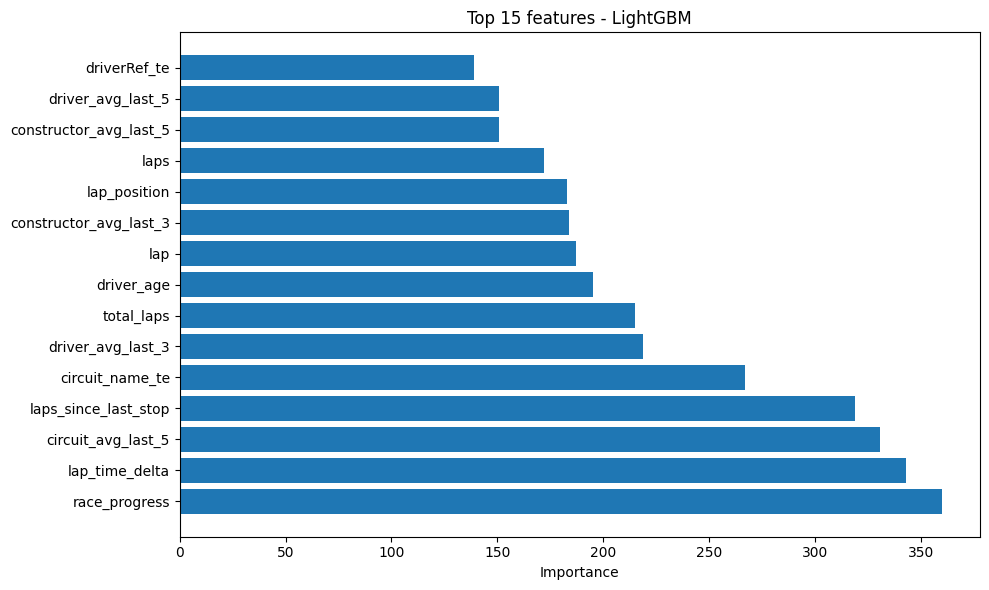


Top 10 features :
   race_progress                  : 360
   lap_time_delta                 : 343
   circuit_avg_last_5             : 331
   laps_since_last_stop           : 319
   circuit_name_te                : 267
   driver_avg_last_3              : 219
   total_laps                     : 215
   driver_age                     : 195
   lap                            : 187
   constructor_avg_last_3         : 184


In [57]:
# ============================================================================
# CELLULE 20 - Feature Importance
# ============================================================================

print("="*60)
print("📊 FEATURE IMPORTANCE")
print("="*60)

# Use the numeric columns that the model was actually trained on
importance = pd.DataFrame({
    'feature': X_tr_imp_df.columns, # Use columns from the DataFrame used for imputation
    'importance': best_lgbm.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'])
plt.xlabel('Importance')
plt.title('Top 15 features - LightGBM')
plt.tight_layout()
plt.show()

print("\nTop 10 features :")
for i, row in importance.head(10).iterrows():
    print(f"   {row['feature']:30s} : {row['importance']:.0f}")

📊 ANALYSE DES RÉSIDUS


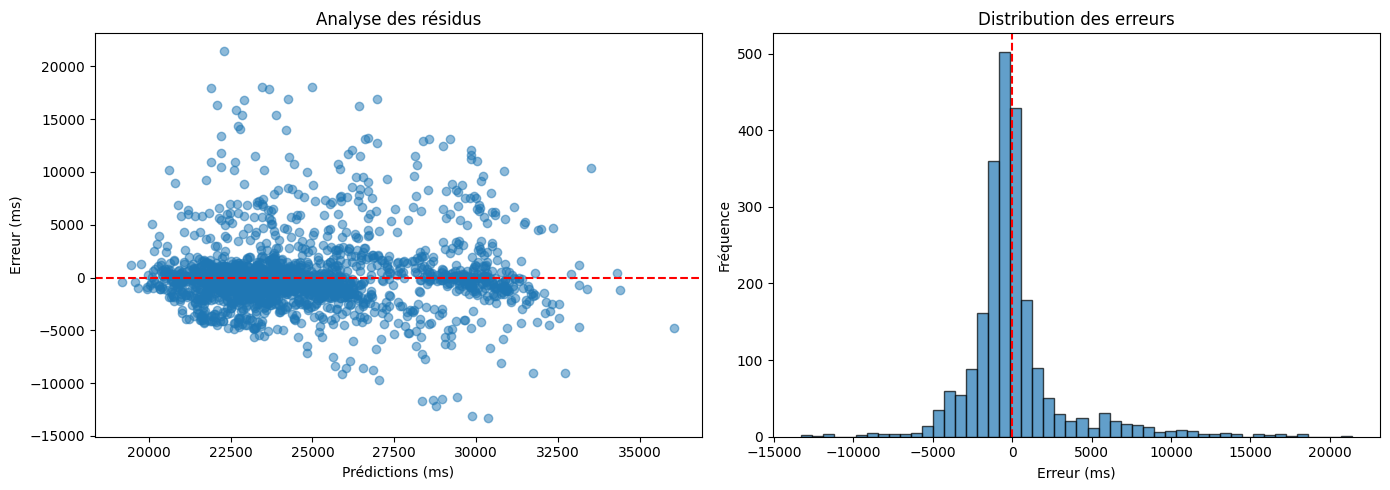

Erreur moyenne : 49.9 ms
Écart-type des erreurs : 3143.6 ms
Erreur médiane : -346.5 ms


In [58]:
# ============================================================================
# CELLULE 21 - Analyse des résidus
# ============================================================================

print("="*60)
print("📊 ANALYSE DES RÉSIDUS")
print("="*60)

y_pred = best_lgbm.predict(X_te_imp)
errors = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Prédictions vs erreurs
axes[0].scatter(y_pred, errors, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Prédictions (ms)')
axes[0].set_ylabel('Erreur (ms)')
axes[0].set_title('Analyse des résidus')

# Graphique 2 : Distribution des erreurs
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Erreur (ms)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des erreurs')

plt.tight_layout()
plt.show()

print(f"Erreur moyenne : {errors.mean():.1f} ms")
print(f"Écart-type des erreurs : {errors.std():.1f} ms")
print(f"Erreur médiane : {np.median(errors):.1f} ms")

In [59]:
# ============================================================================
# CELLULE 22 - Sauvegarde des modèles
# ============================================================================

import joblib
import os

SAVE_DIR = "/content/drive/MyDrive/datasets/f1_ergast2/models"
os.makedirs(SAVE_DIR, exist_ok=True)

# Déterminer le meilleur modèle
best_model_obj = best_lgbm if results_lgbm["RMSE_test"] < results_xgb["RMSE_test"] else best_xgb

# Sauvegarde du modèle
joblib.dump(best_model_obj, f"{SAVE_DIR}/best_model.pkl")
print(f"✅ Modèle sauvegardé : {SAVE_DIR}/best_model.pkl")

# Sauvegarde de l'imputer (nécessaire pour la prédiction)
joblib.dump(imputer, f"{SAVE_DIR}/imputer.pkl")
print(f"✅ Imputer sauvegardé : {SAVE_DIR}/imputer.pkl")

# Sauvegarde des colonnes (pour la cohérence des features)
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, f"{SAVE_DIR}/feature_columns.pkl")
print(f"✅ Features sauvegardées : {len(feature_columns)} colonnes")

# Sauvegarde des résultats
results_df = pd.DataFrame([results_baseline, results_lgbm, results_xgb])
results_df.to_csv(f"{SAVE_DIR}/model_results.csv", index=False)
print(f"✅ Résultats sauvegardés : {SAVE_DIR}/model_results.csv")

print("\n" + "="*60)
print("📦 RÉCAPITULATIF DES FICHIERS SAUVEGARDÉS")
print("="*60)
print(f"   📁 Dossier : {SAVE_DIR}")
print(f"   📄 best_model.pkl      → Modèle LightGBM/XGBoost entraîné")
print(f"   📄 imputer.pkl         → Imputer (médiane) pour les NaN")
print(f"   📄 feature_columns.pkl → Liste des colonnes d'entrée")
print(f"   📄 model_results.csv   → Performances des modèles")
print("="*60)

# Test de chargement
print("\n🔍 TEST DE CHARGEMENT :")
test_model = joblib.load(f"{SAVE_DIR}/best_model.pkl")
test_imputer = joblib.load(f"{SAVE_DIR}/imputer.pkl")
test_features = joblib.load(f"{SAVE_DIR}/feature_columns.pkl")
print(f"   ✅ Modèle chargé : {type(test_model).__name__}")
print(f"   ✅ Imputer chargé : {type(test_imputer).__name__}")
print(f"   ✅ {len(test_features)} features chargées")

print("\n💡 Pour prédire sur de nouvelles données :")
print("   model = joblib.load('best_model.pkl')")
print("   imputer = joblib.load('imputer.pkl')")
print("   X_new_imputed = imputer.transform(X_new)")
print("   predictions = model.predict(X_new_imputed)")

✅ Modèle sauvegardé : /content/drive/MyDrive/datasets/f1_ergast2/models/best_model.pkl
✅ Imputer sauvegardé : /content/drive/MyDrive/datasets/f1_ergast2/models/imputer.pkl
✅ Features sauvegardées : 38 colonnes
✅ Résultats sauvegardés : /content/drive/MyDrive/datasets/f1_ergast2/models/model_results.csv

📦 RÉCAPITULATIF DES FICHIERS SAUVEGARDÉS
   📁 Dossier : /content/drive/MyDrive/datasets/f1_ergast2/models
   📄 best_model.pkl      → Modèle LightGBM/XGBoost entraîné
   📄 imputer.pkl         → Imputer (médiane) pour les NaN
   📄 feature_columns.pkl → Liste des colonnes d'entrée
   📄 model_results.csv   → Performances des modèles

🔍 TEST DE CHARGEMENT :
   ✅ Modèle chargé : LGBMRegressor
   ✅ Imputer chargé : SimpleImputer
   ✅ 38 features chargées

💡 Pour prédire sur de nouvelles données :
   model = joblib.load('best_model.pkl')
   imputer = joblib.load('imputer.pkl')
   X_new_imputed = imputer.transform(X_new)
   predictions = model.predict(X_new_imputed)


In [61]:
# ============================================================================
# CELLULE 23 - Exemple de prédiction (optionnel)
# ============================================================================

print("="*60)
print("📊 EXEMPLE DE PRÉDICTION SUR LE TEST SET")
print("="*60)

# Prendre les 5 premières lignes du test set, en utilisant les données déjà prétraitées numériquement
X_sample = X_te_imp_df.head(5)
y_sample = y_test.head(5)

# Appliquer l'imputer
X_sample_imputed = imputer.transform(X_sample)

# Prédire
predictions = best_model_obj.predict(X_sample_imputed)

# Afficher les résultats
comparison = pd.DataFrame({
    'Durée réelle (ms)': y_sample.values,
    'Durée prédite (ms)': predictions,
    'Erreur (ms)': y_sample.values - predictions,
    'Erreur (%)': ((y_sample.values - predictions) / y_sample.values * 100).round(1)
})

print(comparison.to_string(index=False))
print(f"\n📊 Erreur moyenne sur l'échantillon : {comparison['Erreur (ms)'].mean():.1f} ms")
print(f"📊 Erreur moyenne (%) : {comparison['Erreur (%)'].mean():.1f}%")

📊 EXEMPLE DE PRÉDICTION SUR LE TEST SET
 Durée réelle (ms)  Durée prédite (ms)  Erreur (ms)  Erreur (%)
           25201.0        24568.655269   632.344731         2.5
           25796.0        24058.911863  1737.088137         6.7
           25579.0        24424.351606  1154.648394         4.5
           25365.0        25262.472993   102.527007         0.4
           24909.0        24388.217599   520.782401         2.1

📊 Erreur moyenne sur l'échantillon : 829.5 ms
📊 Erreur moyenne (%) : 3.2%
